# Tarea 3

**Objetivo:** Utilizar modelos de redes convolucionales para clasificación.

El objetivo es utilizar las imágenes de training para entrenar una red convolucional como la que vimos en clase. Se deben crear 2 modelos, uno es una regresión logística y el otro una red convolucional. Se deben hacer 2 envíos en kaggle uno con los resultados de la regresión y los otros con la convolución.

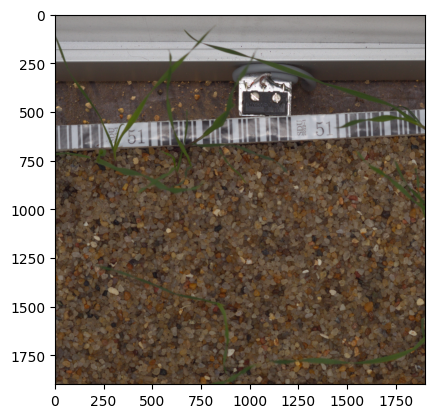

In [6]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, preprocessing
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

plant_types = []

train_dir = os.fsencode("data/train/")
test_dir = os.fsencode("data/test/")

def plot_image(path, label=None):
  img = Image.open(path)
  plt.imshow(img)
  plt.xlabel(label)
  plt.show()

plot_image("data/train/Black-grass/0ace21089.png")

## Regresión logística

In [2]:
tr = tf.keras.utils.image_dataset_from_directory(
    train_dir.decode(),
    validation_split=0.2,
    subset="training",
    seed=4014,
    image_size=(64,64)
)

ts = tf.keras.utils.image_dataset_from_directory(
    train_dir.decode(),
    validation_split=0.2,
    subset="validation",
    seed=4014,
    image_size=(64,64)
)

def preprocess_lgr_images(dataset):
    images = []
    labels = []
    for img, l in dataset:
        images.append(img.numpy().reshape(img.shape[0], -1)) # Flatten
        labels.append(l.numpy())
    flat_images = np.concatenate(images, axis=0)
    flat_labels = np.concatenate(labels, axis=0)
    return flat_images, flat_labels

xr, yr = preprocess_lgr_images(tr)

lgr = LogisticRegression(max_iter=500, random_state=42)
lgr.fit(xr, yr)

Found 5406 files belonging to 16 classes.
Using 4325 files for training.


2025-05-25 12:57:38.090479: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 5406 files belonging to 16 classes.
Using 1081 files for validation.


2025-05-25 12:57:46.334677: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/smorenova/Projects/EST_III_UCO/tarea3/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=500, random_state=42)

TRAIN ACC: 0.9993063583815028


2025-05-25 13:02:56.276215: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


TEST ACC: 0.41905642923219244


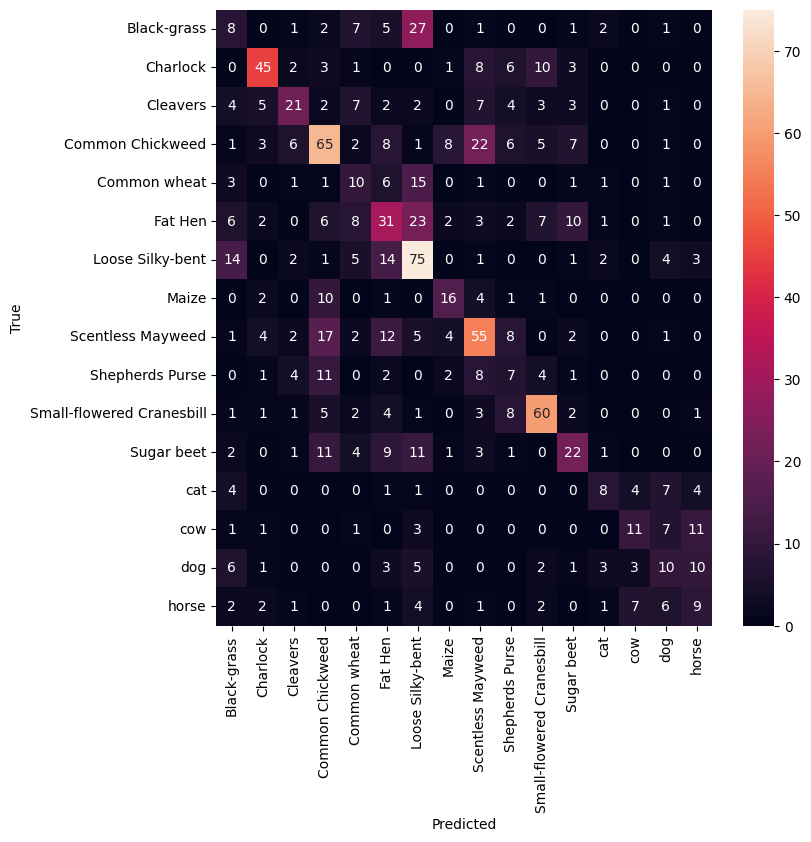

In [3]:
yr_hat = lgr.predict(xr)
print("TRAIN ACC:", accuracy_score(yr, yr_hat))

xs, ys = preprocess_lgr_images(ts)
ys_hat = lgr.predict(xs)
print("TEST ACC:", accuracy_score(ys, ys_hat))

cfm = confusion_matrix(ys, ys_hat)

plt.figure(figsize=(8, 8))
sns.heatmap(cfm, annot=True, fmt='d', xticklabels=ts.class_names, yticklabels=ts.class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

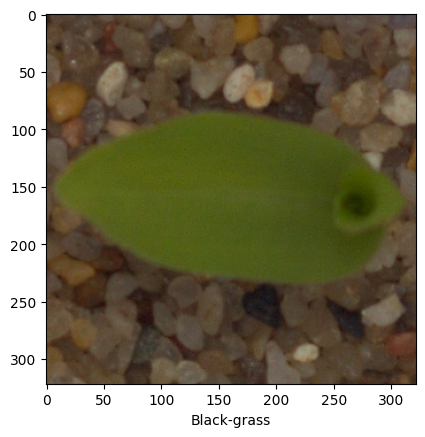

In [7]:
sample = tf.keras.utils.load_img("data/test/0f6cbe5e8.png", target_size=(64,64))
sample_arr = tf.keras.utils.img_to_array(sample)
sample_flat = sample_arr.reshape(-1,sample_arr.shape[0]*sample_arr.shape[1]*sample_arr.shape[2])
sample_pred = lgr.predict(sample_flat)
plot_image("data/test/0f6cbe5e8.png", tr.class_names[np.argmax(sample_pred)])

def predict_labels_lgr(dir):
    preproc = []
    files = []
    for img in os.listdir(dir):
        loaded = tf.keras.utils.load_img(f"data/test/{img.decode()}", target_size=(64,64))
        loaded_arr = tf.keras.utils.img_to_array(loaded)
        preproc.append(loaded_arr)
        files.append(img.decode())

    preproc = np.array(preproc)
    samples = preproc.shape[0]
    px = preproc.shape[1]*preproc.shape[2]*preproc.shape[3]
    flat_images = preproc.reshape((samples, px))

    pred = lgr.predict(flat_images)

    return files, [tr.class_names[i] for i in pred]

f, l = predict_labels_lgr(test_dir)

output = pd.DataFrame({
    "file": f,
    "label": l
})

output.to_csv("output/lgr.csv", index=False)

## Red neuronal convolucional

Found 5406 files belonging to 16 classes.
Using 4325 files for training.
Found 5406 files belonging to 16 classes.
Using 1081 files for validation.


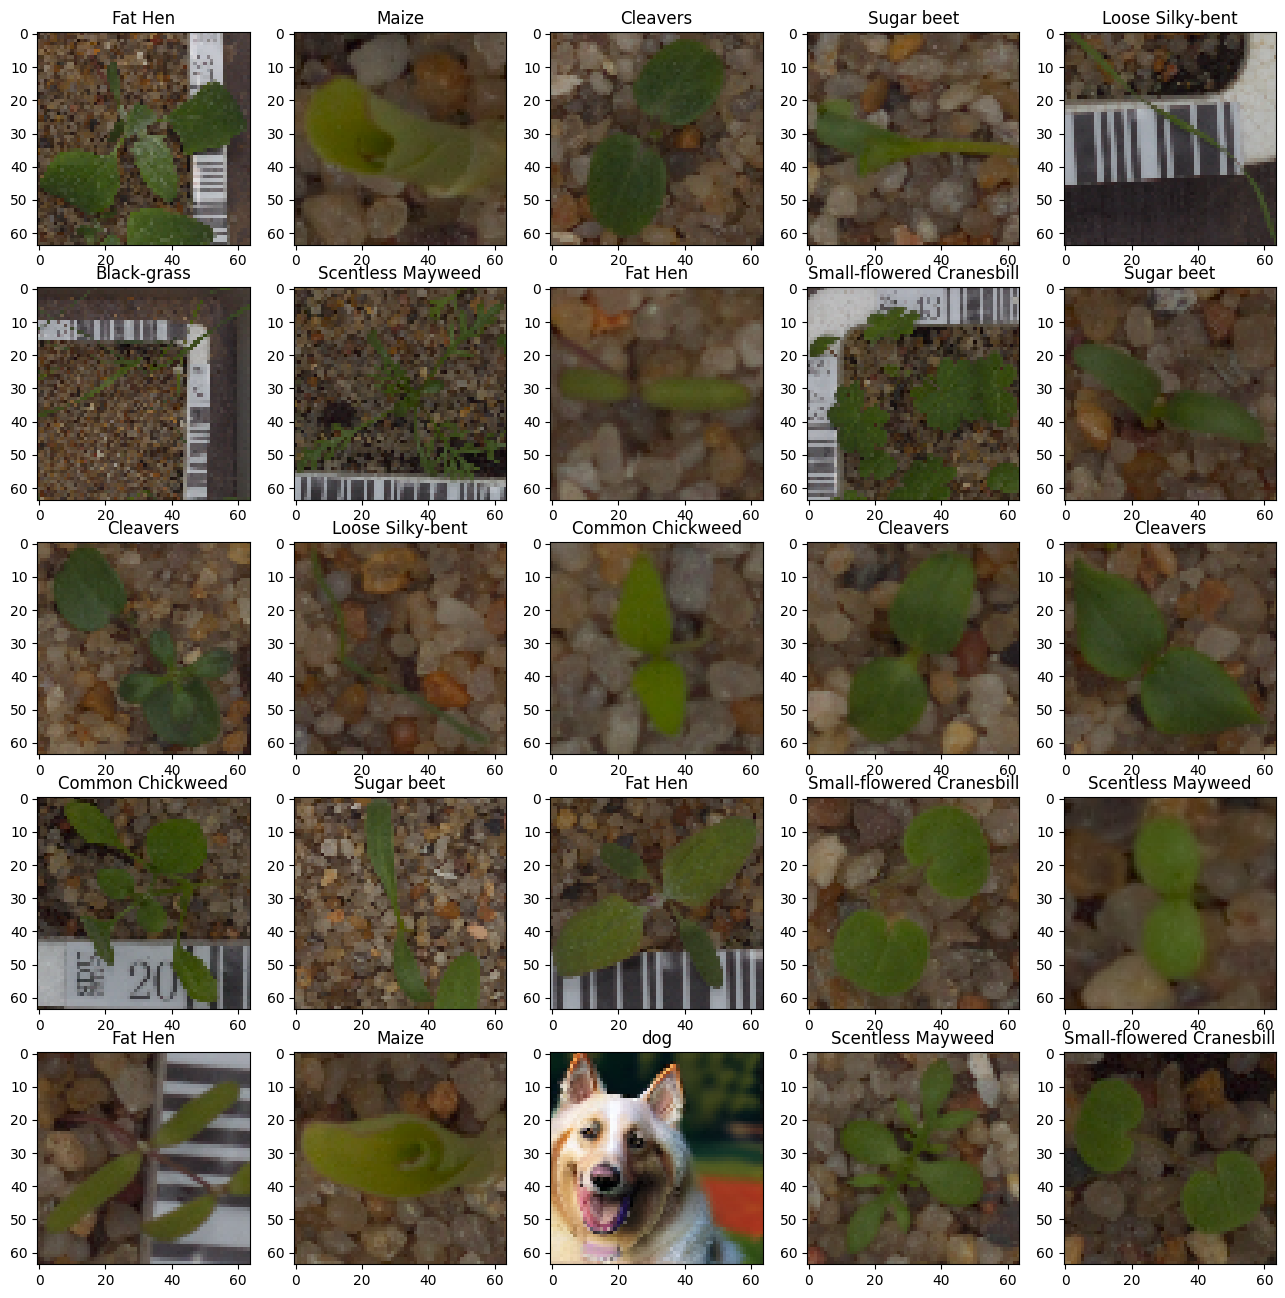

In [8]:
tr = tf.keras.utils.image_dataset_from_directory(
    train_dir.decode(),
    validation_split=0.2,
    subset="training",
    seed=7527,
    image_size=(64,64)
)

ts = tf.keras.utils.image_dataset_from_directory(
    train_dir.decode(),
    validation_split=0.2,
    subset="validation",
    seed=7527,
    image_size=(64,64)
)

plt.figure(figsize=(16,16))
for images, labels in tr.take(1):
  for i in range(25):
    ax = plt.subplot(5, 5, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(tr.class_names[labels[i]])

In [9]:
cnn = models.Sequential()

cnn.add(layers.Input(shape=(64, 64, 3)))

cnn.add(layers.Conv2D(32, (3,3), activation="relu"))
cnn.add(layers.BatchNormalization())
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.Conv2D(64, (3,3), activation="relu", padding="same"))
cnn.add(layers.BatchNormalization())
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.Conv2D(128, (3,3), activation="relu", padding="same"))
cnn.add(layers.BatchNormalization())
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.Flatten())
cnn.add(layers.Dense(256, activation='relu'))
cnn.add(layers.BatchNormalization())
cnn.add(layers.Dropout(0.5))
cnn.add(layers.Dense(128, activation='relu'))
cnn.add(layers.BatchNormalization())
cnn.add(layers.Dropout(0.25))
cnn.add(layers.Dense(16, activation='softmax'))

cnn.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 31, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,736,528 (6.62 MB)

 Trainable params: 1,735,312 (6.62 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [10]:
cnn.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer='adam', metrics=["accuracy"])
cnn.fit(tr, epochs=10, callbacks=[early_stopping])

Epoch 1/10


/home/smorenova/Projects/EST_III_UCO/tarea3/.venv/lib/python3.9/site-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


136/136 ━━━━━━━━━━━━━━━━━━━━ 41s 250ms/step - accuracy: 0.2578 - loss: 2.5189
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 247ms/step - accuracy: 0.5662 - loss: 1.3486
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 33s 243ms/step - accuracy: 0.6482 - loss: 1.0693
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 33s 245ms/step - accuracy: 0.7134 - loss: 0.8495
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 33s 243ms/step - accuracy: 0.7614 - loss: 0.6976
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 247ms/step - accuracy: 0.7823 - loss: 0.6192
Epoch 7/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 246ms/step - accuracy: 0.7913 - loss: 0.5871
Epoch 8/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 36s 261ms/step - accuracy: 0.7631 - loss: 0.6789
Epoch 9/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 35s 253ms/step - accuracy: 0.8401 - loss: 0.4769
Epoch 10/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 35s 255ms/step - accuracy: 0.8735 - loss: 0.3614


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


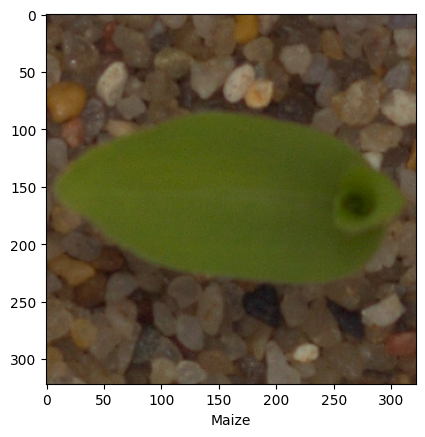

34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.7384 - loss: 0.7746


In [12]:
sample = tf.keras.utils.load_img("data/test/0f6cbe5e8.png", target_size=(64,64))
sample_arr = tf.keras.utils.img_to_array(sample)
sample_pred = cnn.predict(np.array([sample_arr]))
plot_image("data/test/0f6cbe5e8.png", tr.class_names[np.argmax(sample_pred, axis=1)[0]])

results = cnn.evaluate(ts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10

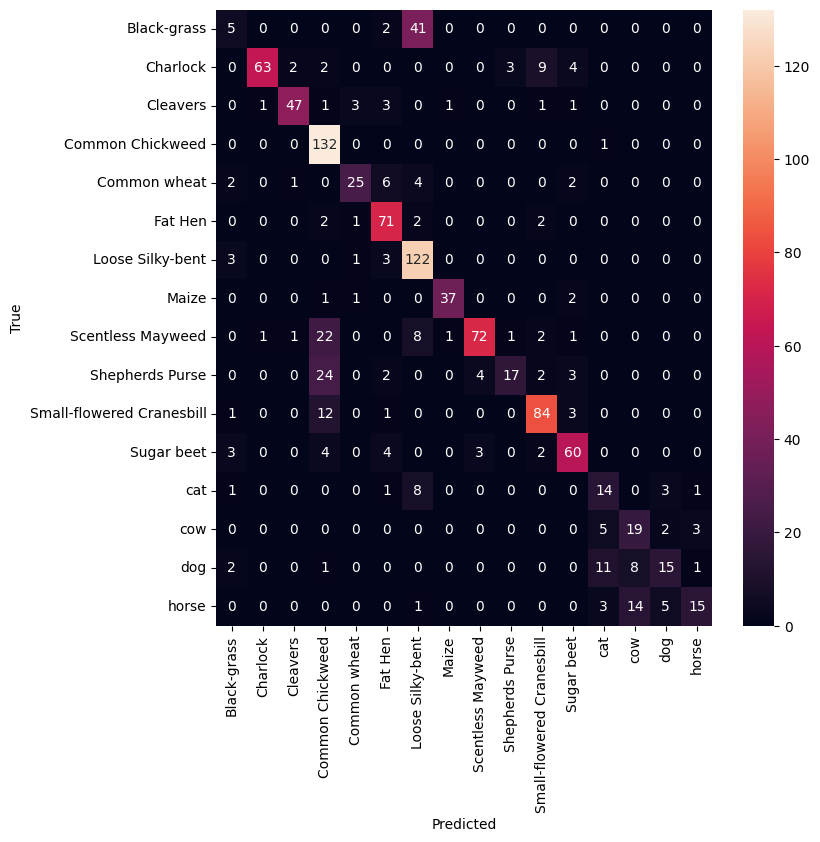

In [15]:
ys = []
ys_hat = []

for images, labels in ts:
    ys.extend(labels.numpy())
    pred = cnn.predict(images)
    pred_idx = np.argmax(pred, axis=1)
    ys_hat.extend(pred_idx)

cfm = confusion_matrix(ys, ys_hat)

plt.figure(figsize=(8, 8))
sns.heatmap(cfm, annot=True, fmt='d', xticklabels=ts.class_names, yticklabels=ts.class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [16]:
def predict_labels_cnn(dir):
    preproc = []
    files = []
    for img in os.listdir(dir):
        loaded = tf.keras.utils.load_img(f"data/test/{img.decode()}", target_size=(64,64))
        loaded_arr = tf.keras.utils.img_to_array(loaded)
        preproc.append(loaded_arr)
        files.append(img.decode())

    preproc = np.array(preproc)

    pred = cnn.predict(preproc)
    pred_idx = np.argmax(pred, axis=1)

    return files, [tr.class_names[i] for i in pred_idx]

f, l = predict_labels_cnn(test_dir)

output = pd.DataFrame({
    "file": f,
    "label": l
})

output.to_csv("output/cnn.csv", index=False)

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
